In [60]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

In [79]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "red_blue_direct",
    ["teal", "royalblue"]
)

### SHAP beeswarm plots - chosen top features 


Running SHAP for: XGB
Running SHAP for: XGB - Mean Fluorescence Intensity


/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


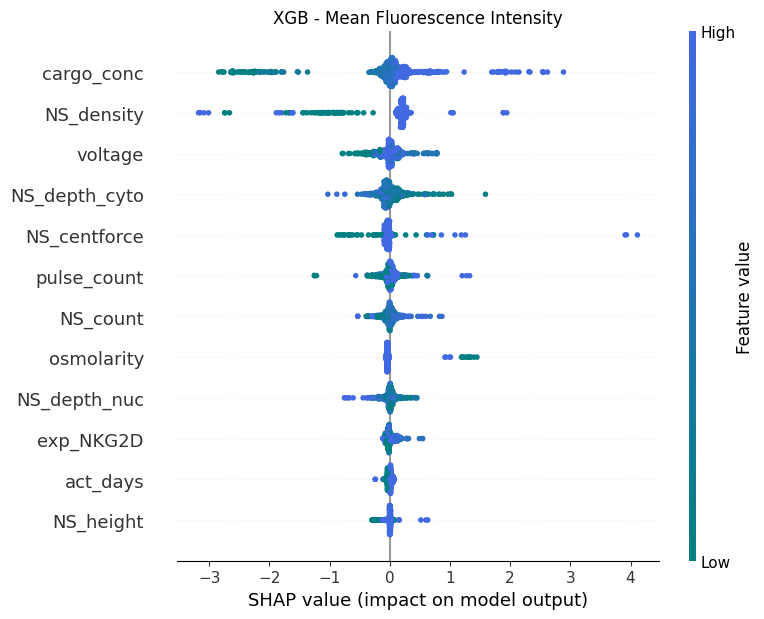

Running SHAP for: XGB - Cell viability


/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


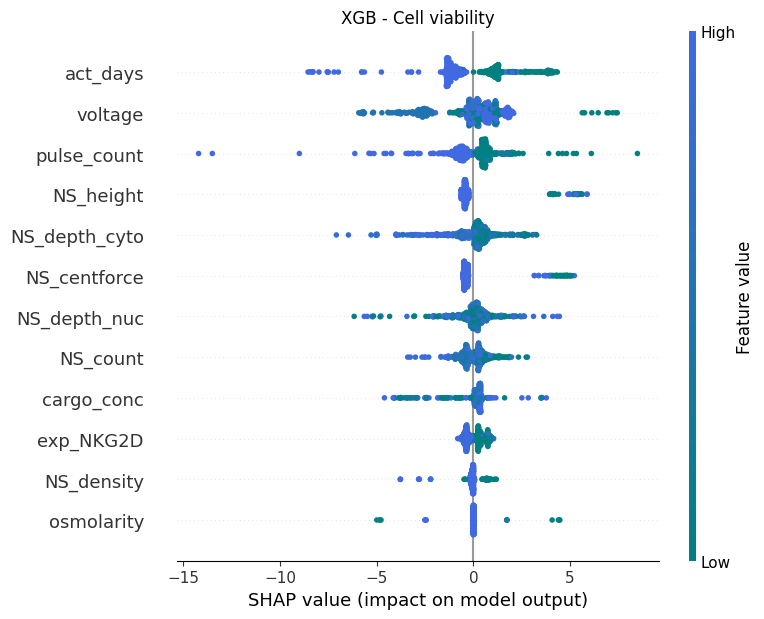

Running SHAP for: XGB - Transfection efficiency


/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


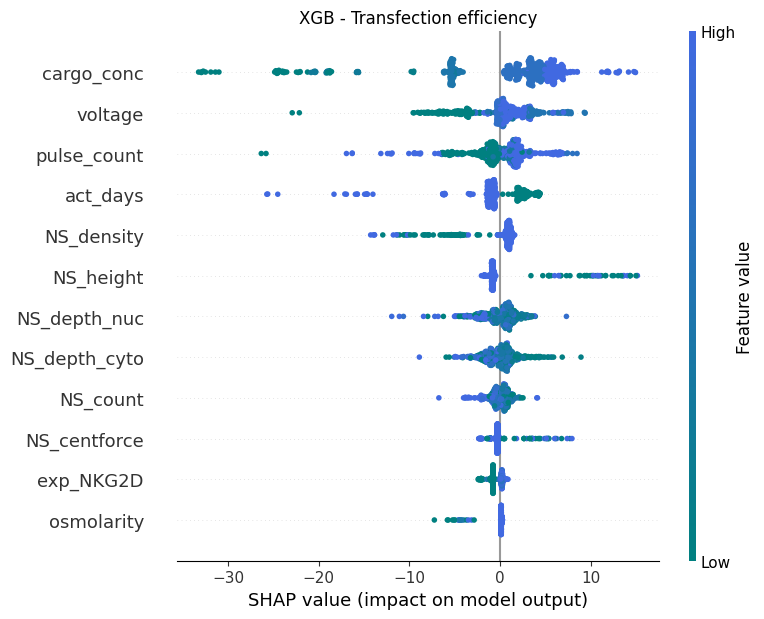


Running SHAP for: NGB
Running SHAP for: NGB - Mean Fluorescence Intensity


PermutationExplainer explainer: 615it [13:35,  1.34s/it]                         
/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


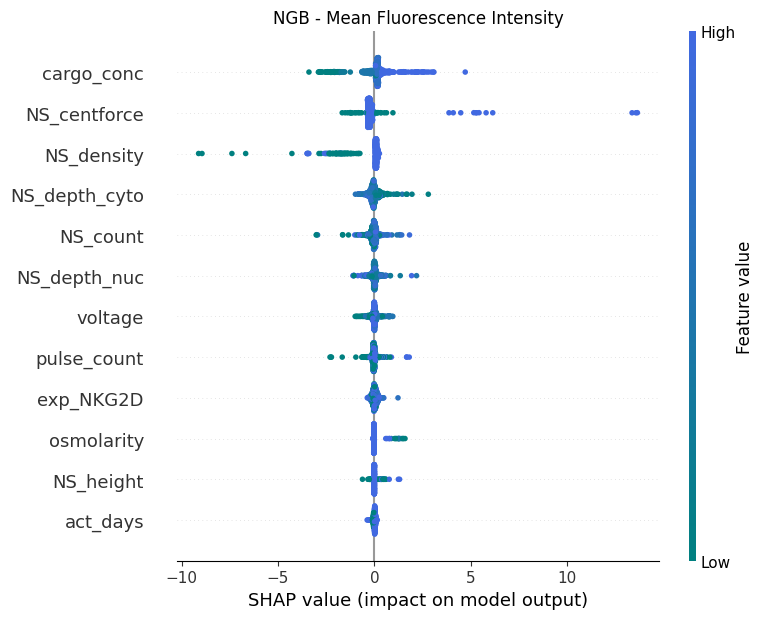

Running SHAP for: NGB - Cell viability


PermutationExplainer explainer: 615it [07:16,  1.38it/s]                         
/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


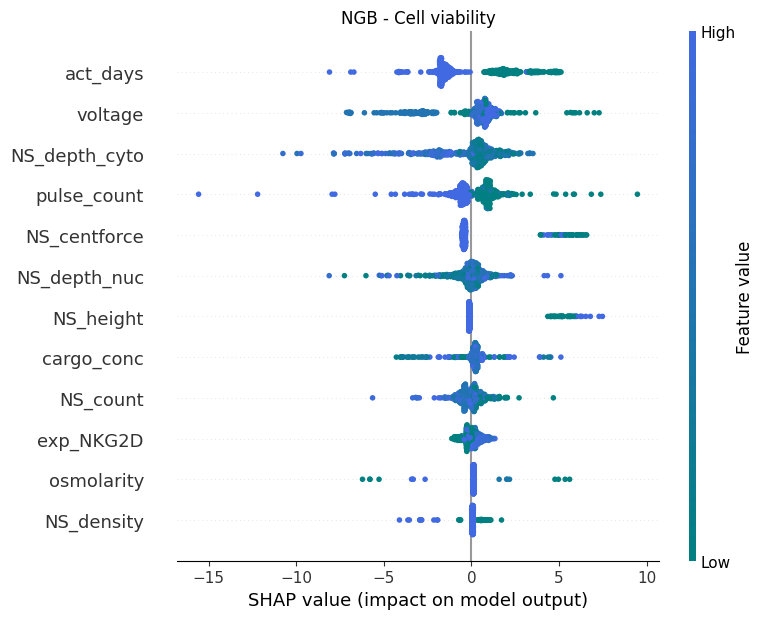

Running SHAP for: NGB - Transfection efficiency


PermutationExplainer explainer: 615it [10:43,  1.05s/it]                         
/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_14817/3197210347.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


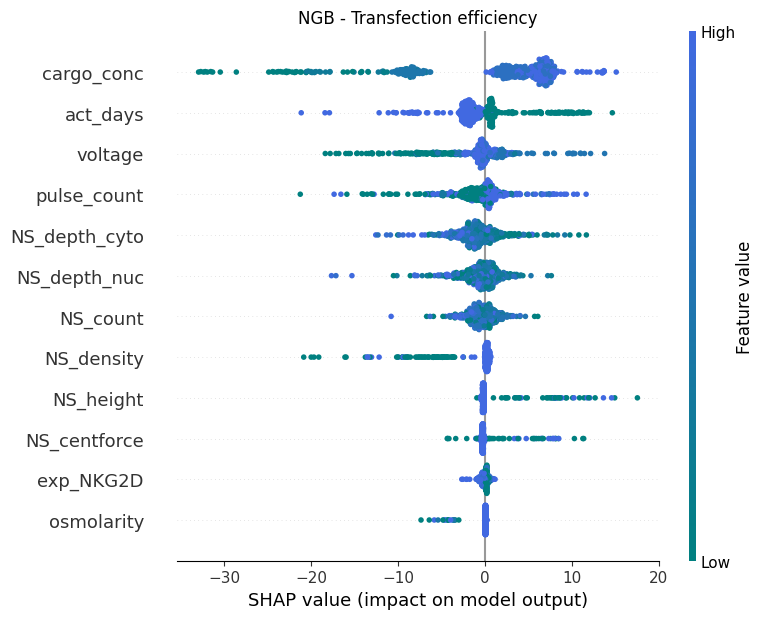

In [82]:
top_features = [
    "cargo_conc", "NS_density", "NS_centforce", "voltage", 
    "NS_height", "NS_depth_nuc", "NS_depth_cyto", "pulse_count",
    "act_days", "NS_count", "osmolarity", "exp_NKG2D"
]

model_files = {
    'XGB': "trained_models2_pkl/trained_models2_34_feat_XGB_fly.pkl",
    'NGB': "trained_models2_pkl/trained_models2_34_feat_NGB_fly.pkl",
}

for model_name, file_path in model_files.items():
    
    print(f"\nRunning SHAP for: {model_name}")
    df = pd.read_pickle(file_path)
    models = df
    
    for output_name, model in models.items():
        
        print(f"Running SHAP for: {model_name} - {output_name}")
        
        if model_name == 'XGB':
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X)
        elif model_name == 'NGB':
            explainer = shap.Explainer(model.predict, X)
            shap_values = explainer(X)
        
        valid_features = [f for f in top_features if f in X.columns]
        
        feature_idx = [X.columns.get_loc(f) for f in valid_features]
        
        shap_subset = shap_values[:, feature_idx]
        X_subset = X[valid_features]
        plt.figure(figsize=(8,6))
        
        shap.summary_plot(
            shap_subset,
            X_subset,
            cmap=custom_cmap,
            show=False
        )
        
        plt.title(f"{model_name} - {output_name}")
        plt.tight_layout()
        
        plt.savefig(f"SHAP_beeswram_{model_name}_{output_name}.png", dpi=800, bbox_inches='tight')
        
        plt.show()
        plt.close()

### Feature importances plot 


Processing: Mean Fluorescence Intensity


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:1476: UserWarning: Translating model_output="raw" to model_output=0 for the 0-th parameter in the distribution. Use model_output=0 directly to avoid this warning.
  warnings.warn(


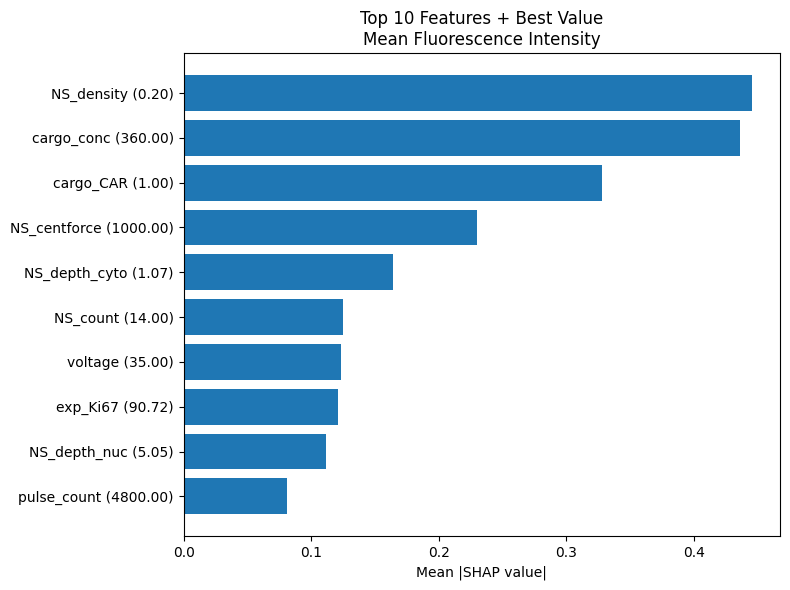


Processing: Cell viability


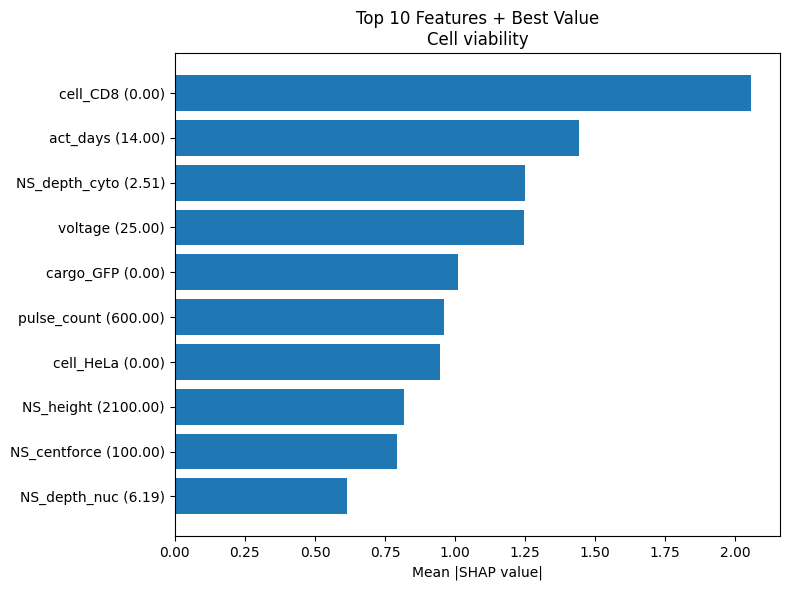


Processing: Transfection efficiency


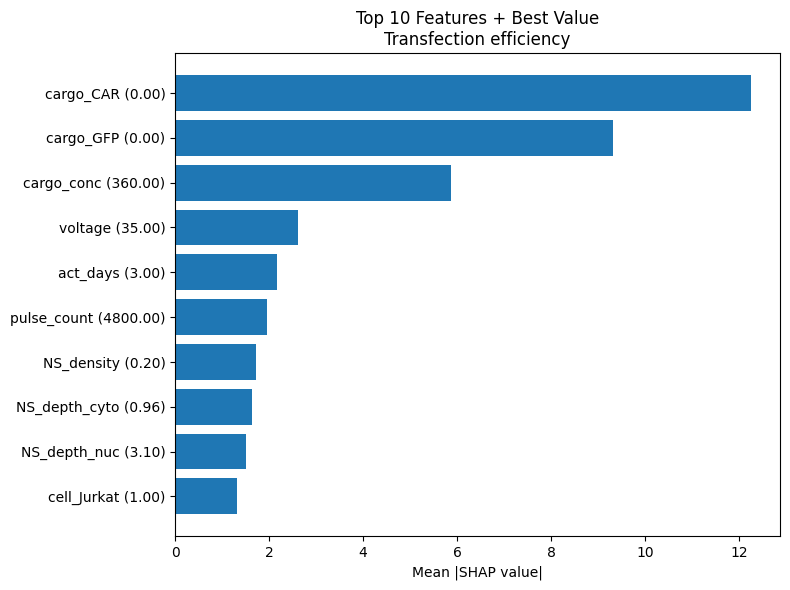

In [94]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("34_feat_dataset.xlsx")

X_raw = df.iloc[:, :-5].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Store scaled version (used for model + SHAP)
X = pd.DataFrame(
    X_scaled,
    columns=X_raw.columns,
    index=X_raw.index
)

# X_original version for interpretation
X_original = X_raw.copy()

for output_name, model in models.items():
    
    print(f"\nProcessing: {output_name}")
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    shap_values = np.array(shap_values)
    
    # mean absolute SHAP
    mean_shap = np.abs(shap_values).mean(axis=0)
    
    # sort features
    sorted_idx = np.argsort(mean_shap)[::-1]
    
    top_n = 10
    top_idx = sorted_idx[:top_n]
    
    feature_names = X.columns[top_idx]
    
    best_values = []
    
    # Present corresponding best value per feature (unscaled values)
    for i in top_idx:
        shap_col = shap_values[:, i]
        feature_col = X_original.iloc[:, i]

        # index value where SHAP is maximum
        best_idx = np.argmax(shap_col)
        best_val = feature_col.iloc[best_idx]
        best_values.append(best_val)
    
    # creating labels with REAL values
    labels = [
        f"{feat} ({val:.2f})"
        for feat, val in zip(feature_names, best_values)
    ]

    plt.figure(figsize=(8,6))
    plt.barh(labels[::-1], mean_shap[top_idx][::-1])
    
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top 10 Features + Best Value\n{output_name}")
    plt.tight_layout()
    #plt.savefig(f"Top10_with_best_{output_name}.png", dpi=300)
    plt.show()
    plt.close()


Processing SHAP for: XGB


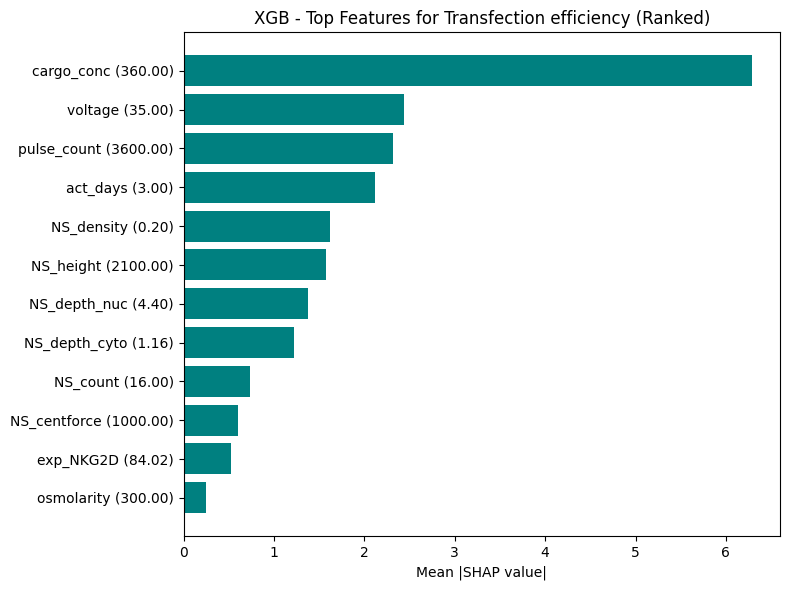


Processing SHAP for: NGB


PermutationExplainer explainer: 615it [09:45,  1.04it/s]                         


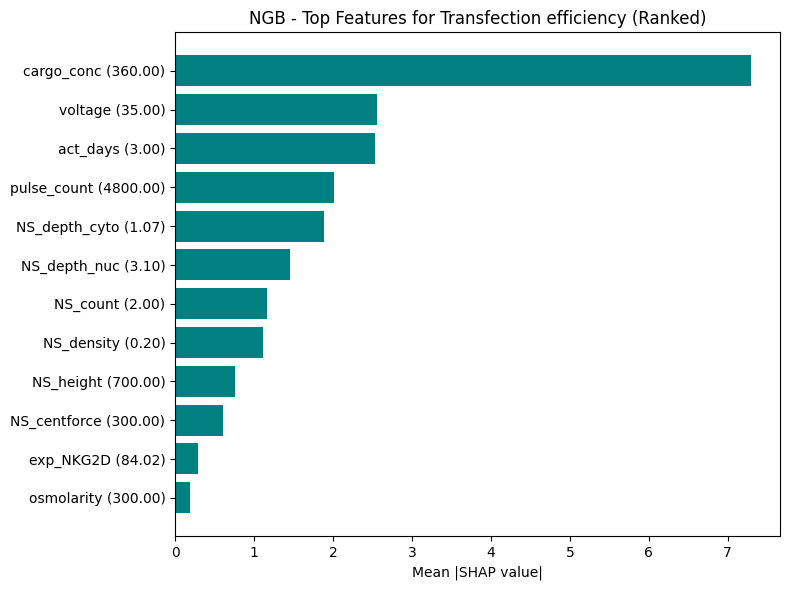

In [93]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle

top_features = [
    "cargo_conc", "NS_density", "NS_centforce", "voltage", 
    "NS_height", "NS_depth_nuc", "NS_depth_cyto", "pulse_count",
    "act_days", "NS_count", "osmolarity", "exp_NKG2D"
]

model_files = {
    'XGB': "trained_models2_pkl/trained_models2_34_feat_XGB_fly.pkl",
    'NGB': "trained_models2_pkl/trained_models2_34_feat_NGB_fly.pkl",
}

df = pd.read_excel("34_feat_dataset.xlsx")

X_raw = df.iloc[:, :-5].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, columns=X_raw.columns, index=X_raw.index)
X_original = X_raw.copy()

for model_name, file_path in model_files.items():
    
    print(f"\nProcessing SHAP for: {model_name}")
    
    with open(file_path, 'rb') as f:
        models = pickle.load(f)  # assuming dict of trained models
    
    # Only take "Transfection efficiency" output
    output_name = "Transfection efficiency"
    if output_name not in models:
        print(f"Output {output_name} not found in {model_name}, skipping.")
        continue
    
    model = models[output_name]
    
    if model_name in ['XGB']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X)
    elif model_name == 'NGB':
        explainer = shap.Explainer(model.predict, X)
        shap_values = explainer(X)
    
    valid_features = [f for f in top_features if f in X.columns]
    feature_idx = [X.columns.get_loc(f) for f in valid_features]
    
    shap_subset = shap_values[:, feature_idx]
    shap_array = np.abs(shap_subset.values)
    
    # Compute mean |SHAP| per feature
    mean_shap = shap_array.mean(axis=0)
    
    sorted_idx = np.argsort(mean_shap)[::-1]
    sorted_features = [valid_features[i] for i in sorted_idx]
    sorted_mean_shap = mean_shap[sorted_idx]
    
    #find original unscaled corrseponding value for each feature
    best_values = []
    for i in sorted_idx:
        shap_col = shap_subset.values[:, i]  # use raw SHAP, not absolute
        feature_col = X_original[valid_features[i]]
        pos_indices = np.where(shap_col > 0)[0]
        if len(pos_indices) == 0:
            best_val = np.nan  # no positive contributions
        else:
            best_idx = pos_indices[np.argmax(shap_col[pos_indices])]
            best_val = feature_col.iloc[best_idx]
    
        best_values.append(best_val)
    
    # Plot labels with unscaled values
    labels = [f"{feat} ({val:.2f})" for feat, val in zip(sorted_features, best_values)]
    
    plt.figure(figsize=(8,6))
    plt.barh(labels[::-1], sorted_mean_shap[::-1], color='teal')
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"{model_name} - Top Features for {output_name} (Ranked)")
    plt.tight_layout()
    plt.savefig(f"TopFeatures_{model_name}_{output_name}.png", dpi=800)
    plt.show()
    plt.close()


Processing SHAP for: XGB


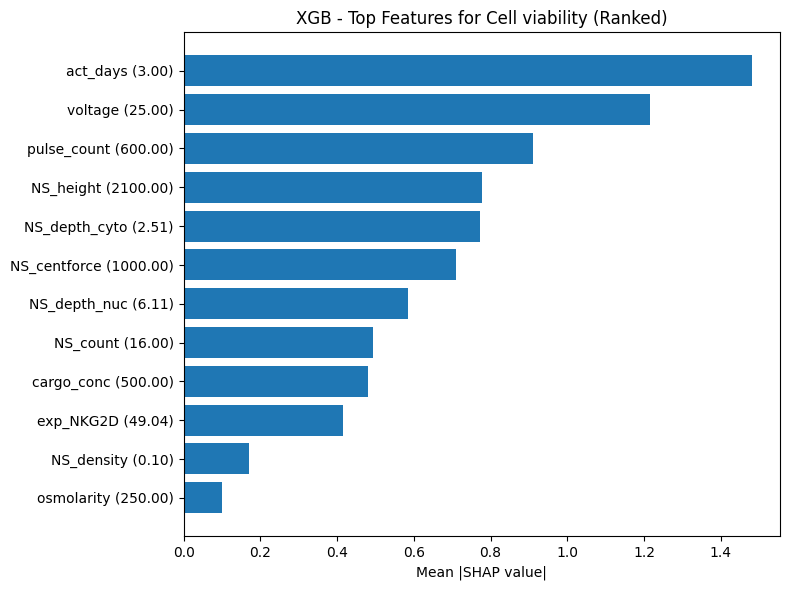


Processing SHAP for: NGB


PermutationExplainer explainer: 615it [06:26,  1.57it/s]                         


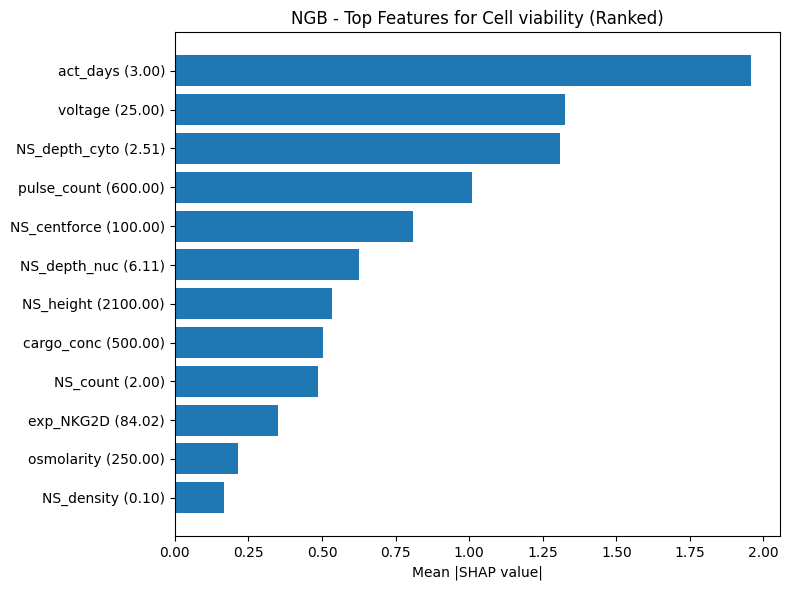

In [92]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle

top_features = [
    "cargo_conc", "NS_density", "NS_centforce", "voltage", 
    "NS_height", "NS_depth_nuc", "NS_depth_cyto", "pulse_count",
    "act_days", "NS_count", "osmolarity", "exp_NKG2D"
]

model_files = {
    'XGB': "trained_models2_pkl/trained_models2_34_feat_XGB_fly.pkl",
    'NGB': "trained_models2_pkl/trained_models2_34_feat_NGB_fly.pkl",
}

df = pd.read_excel("34_feat_dataset.xlsx")

X_raw = df.iloc[:, :-5].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, columns=X_raw.columns, index=X_raw.index)
X_original = X_raw.copy()

for model_name, file_path in model_files.items():
    
    print(f"\nProcessing SHAP for: {model_name}")
    
    with open(file_path, 'rb') as f:
        models = pickle.load(f)  # assuming dict of trained models
    
    # Only take "Cell viability" output
    output_name = "Cell viability"
    if output_name not in models:
        print(f"Output {output_name} not found in {model_name}, skipping.")
        continue
    
    model = models[output_name]
    
    if model_name in ['XGB']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X)
    elif model_name == 'NGB':
        explainer = shap.Explainer(model.predict, X)
        shap_values = explainer(X)
    
    valid_features = [f for f in top_features if f in X.columns]
    feature_idx = [X.columns.get_loc(f) for f in valid_features]
    
    shap_subset = shap_values[:, feature_idx]
    shap_array = np.abs(shap_subset.values)
    
    # Compute mean |SHAP| per feature
    mean_shap = shap_array.mean(axis=0)
    
    sorted_idx = np.argsort(mean_shap)[::-1]
    sorted_features = [valid_features[i] for i in sorted_idx]
    sorted_mean_shap = mean_shap[sorted_idx]
    
    #find original unscaled corrseponding value for each feature
    best_values = []
    for i in sorted_idx:
        shap_col = shap_subset.values[:, i]  # use raw SHAP, not absolute
        feature_col = X_original[valid_features[i]]
        pos_indices = np.where(shap_col > 0)[0]
        if len(pos_indices) == 0:
            best_val = np.nan  # no positive contributions
        else:
            best_idx = pos_indices[np.argmax(shap_col[pos_indices])]
            best_val = feature_col.iloc[best_idx]
    
        best_values.append(best_val)
       
    # Plot labels with unscaled values
    labels = [f"{feat} ({val:.2f})" for feat, val in zip(sorted_features, best_values)]
    
    plt.figure(figsize=(8,6))
    plt.barh(labels[::-1], sorted_mean_shap[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"{model_name} - Top Features for {output_name} (Ranked)")
    plt.tight_layout()
    plt.savefig(f"TopFeatures_{model_name}_{output_name}.png", dpi=800)
    plt.show()
    plt.close()


Processing SHAP for: XGB


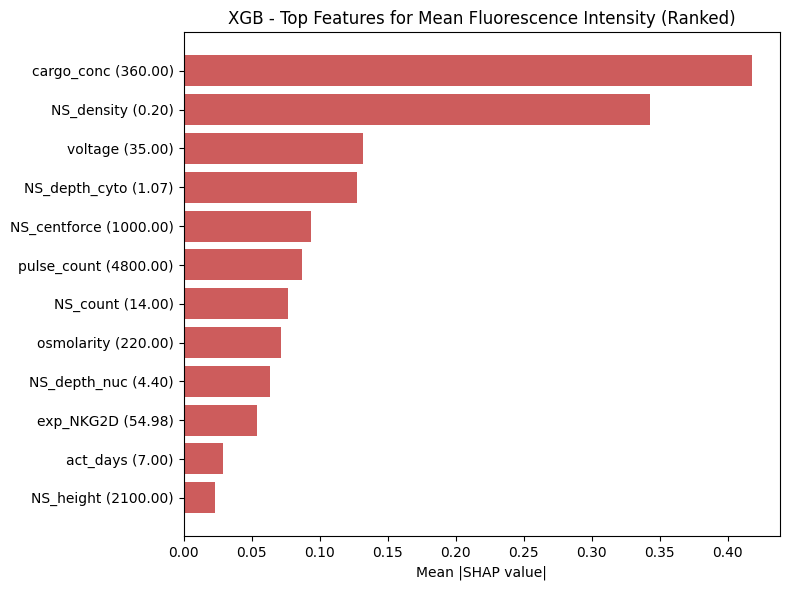


Processing SHAP for: NGB


PermutationExplainer explainer: 615it [13:11,  1.30s/it]                         


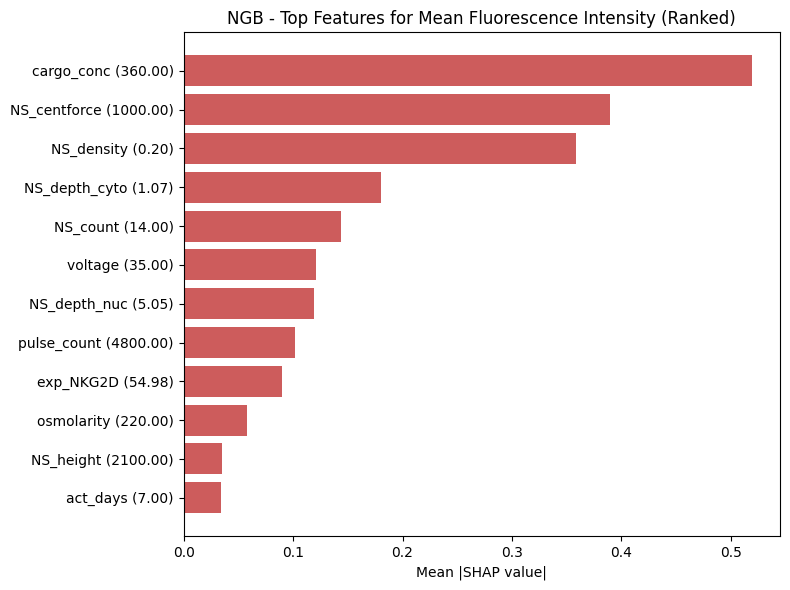

In [91]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle

top_features = [
    "cargo_conc", "NS_density", "NS_centforce", "voltage", 
    "NS_height", "NS_depth_nuc", "NS_depth_cyto", "pulse_count",
    "act_days", "NS_count", "osmolarity", "exp_NKG2D"
]

model_files = {
    'XGB': "trained_models2_pkl/trained_models2_34_feat_XGB_fly.pkl",
    'NGB': "trained_models2_pkl/trained_models2_34_feat_NGB_fly.pkl",
}

df = pd.read_excel("34_feat_dataset.xlsx")

X_raw = df.iloc[:, :-5].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, columns=X_raw.columns, index=X_raw.index)
X_original = X_raw.copy()

for model_name, file_path in model_files.items():
    
    print(f"\nProcessing SHAP for: {model_name}")
    
    with open(file_path, 'rb') as f:
        models = pickle.load(f)  # assuming dict of trained models
    
    # Only take "Mean Fluorescence Intensity" output
    output_name = "Mean Fluorescence Intensity"
    if output_name not in models:
        print(f"Output {output_name} not found in {model_name}, skipping.")
        continue
    
    model = models[output_name]
    
    if model_name in ['XGB']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X)
    elif model_name == 'NGB':
        explainer = shap.Explainer(model.predict, X)
        shap_values = explainer(X)
    
    valid_features = [f for f in top_features if f in X.columns]
    feature_idx = [X.columns.get_loc(f) for f in valid_features]
    
    shap_subset = shap_values[:, feature_idx]
    shap_array = np.abs(shap_subset.values)
    
    # Compute mean |SHAP| per feature
    mean_shap = shap_array.mean(axis=0)
    
    sorted_idx = np.argsort(mean_shap)[::-1]
    sorted_features = [valid_features[i] for i in sorted_idx]
    sorted_mean_shap = mean_shap[sorted_idx]
    
    #find original unscaled corrseponding value for each feature
    best_values = []
    for i in sorted_idx:
        shap_col = shap_subset.values[:, i]  # use raw SHAP, not absolute
        feature_col = X_original[valid_features[i]]
        pos_indices = np.where(shap_col > 0)[0]
        if len(pos_indices) == 0:
            best_val = np.nan  # no positive contributions
        else:
            best_idx = pos_indices[np.argmax(shap_col[pos_indices])]
            best_val = feature_col.iloc[best_idx]
    
        best_values.append(best_val)
    
    # Plot labels with unscaled values
    labels = [f"{feat} ({val:.2f})" for feat, val in zip(sorted_features, best_values)]
    
    plt.figure(figsize=(8,6))
    plt.barh(labels[::-1], sorted_mean_shap[::-1], color='indianred')
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"{model_name} - Top Features for {output_name} (Ranked)")
    plt.tight_layout()
    plt.savefig(f"TopFeatures_{model_name}_{output_name}.png", dpi=800)
    plt.show()
    plt.close()